# Mean Forecast: Fill Rate

This notebook treats the safety-stock target as a **fill rate** (the fraction of demand
served directly from on-hand stock): `FillRateSafetyStock` solves for the buffer that hits
a target fill rate analytically (inverting the normal loss function), rather than requiring
a cost-based grid search over a multiplier.

**Scope note (rewritten against the new strategy-composed API, Task 14):**
janrth's original notebook optimized many articles at once via batch helpers
(`optimize_service_level_factors`/`simulate_replenishment_for_articles`/
`optimize_aggregation_and_service_level_factors`) that were never ported into this repo
(see `io_.py`'s module docstring: the aggregation-window and batch-simulation ecosystem
is out of scope for Tasks 1-13). This rewrite uses `ReplenishmentPolicy`,
`calibration.optimize`, and `simulate_replenishment` directly, looping per article where
the original looped implicitly inside the batch helper. Article counts are reduced from
the original notebook to keep demo runtime reasonable.

In [1]:
from dataclasses import replace
import random

import pandas as pd

from replenishment.io_ import (
    generate_standard_simulation_rows, standard_simulation_rows_to_dataframe,
    split_standard_simulation_rows, replenishment_decision_rows_to_dataframe,
    ReplenishmentDecisionRow,
)
from replenishment.calibration import optimize
from replenishment.simulation import simulate_replenishment
from replenishment.policy import ReplenishmentPolicy
from replenishment.timeseries import TimeSeries
from replenishment.strategies.safety_stock import FillRateSafetyStock
from replenishment.strategies.order_trigger import OrderUpToTrigger, ReorderPointTrigger
from replenishment.viz import plot_replenishment_decisions

### Policy cadence parameters

In [2]:
review_period = 1
forecast_horizon = 1

## 1) Generate Sample Data
We generate synthetic history + forecast rows. Forecast periods are given simulated actuals so we can compare forecast vs. actuals in evaluation.

In [3]:
history_mean = 20.0
history_std = 8.0
forecast_mean = 18.0
forecast_std = 6.0

rows = generate_standard_simulation_rows(
    n_unique_ids=10,
    periods=90,
    history_mean=history_mean,
    history_std=history_std,
    forecast_mean=forecast_mean,
    forecast_std=forecast_std,
    forecast_start_period=60,
    lead_time=3,
    initial_on_hand=25,
    current_stock=25,
    holding_cost_per_unit=1,
    stockout_cost_per_unit=5,
    order_cost_per_order=10,
    seed=7,
)
backtest_rows, evaluation_rows = split_standard_simulation_rows(rows)

# Add simulated actuals for the forecast/evaluation period.
rng = random.Random(7)
def _sample_int(mean: float, std: float) -> int:
    return max(0, int(round(rng.gauss(mean, std))))

evaluation_rows = [
    replace(row, actuals=_sample_int(history_mean, history_std), demand=_sample_int(history_mean, history_std))
    for row in evaluation_rows
]

rows_df = standard_simulation_rows_to_dataframe(backtest_rows + evaluation_rows, library="pandas")
print(f"backtest rows: {len(backtest_rows)}, forecast rows: {len(evaluation_rows)}")
if not evaluation_rows:
    raise ValueError("No forecast rows found. Set forecast_start_period to create forecast rows.")

candidate_fill_rates = [.80, .85, .90, .95, .97, .99]

backtest rows: 600, forecast rows: 300


## 2) Calibrate the target fill rate per article
For each article, sweep candidate fill-rate targets through `calibration.optimize` (which does the train/validation split and cost scoring) and keep the target with the lowest validation cost.

In [4]:
def _group_by_article(rows):
    grouped = {}
    for row in rows:
        grouped.setdefault(row.unique_id, []).append(row)
    for uid in grouped:
        grouped[uid].sort(key=lambda r: r.ds)
    return grouped

In [5]:
backtest_by_article = _group_by_article(backtest_rows)
forecast_by_article = _group_by_article(evaluation_rows)

decision_rows = []
calibration_results = {}
for unique_id, article_backtest in backtest_by_article.items():
    demand = [r.demand for r in article_backtest]
    actuals = [r.actuals for r in article_backtest]
    forecast_values = [r.forecast for r in article_backtest]
    lead_time = article_backtest[0].lead_time

    def candidate_builder(target_fill_rate, forecast_values=forecast_values, actuals=actuals, lead_time=lead_time):
        return ReplenishmentPolicy.order_up_to(
            forecast=TimeSeries.from_values(forecast_values),
            actuals=TimeSeries.from_values(actuals),
            safety_stock=FillRateSafetyStock(target_fill_rate=target_fill_rate),
            lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
        )

    result = optimize(
        candidate_builder=candidate_builder, candidate_values=candidate_fill_rates,
        periods=len(article_backtest), demand=demand, initial_on_hand=article_backtest[0].initial_on_hand,
        lead_time=lead_time, holding_cost_per_unit=article_backtest[0].holding_cost_per_unit,
        stockout_cost_per_unit=article_backtest[0].stockout_cost_per_unit,
        order_cost_per_order=article_backtest[0].order_cost_per_order,
    )
    calibration_results[unique_id] = result

    article_forecast_rows = forecast_by_article.get(unique_id, [])
    if not article_forecast_rows:
        continue
    eval_policy = candidate_builder(
        result.best_value, forecast_values=[r.forecast for r in article_forecast_rows], actuals=actuals,
    )
    current_stock = article_forecast_rows[0].current_stock
    simulation = simulate_replenishment(
        periods=len(article_forecast_rows), demand=[r.demand for r in article_forecast_rows],
        initial_on_hand=current_stock, lead_time=lead_time, policy=eval_policy,
        holding_cost_per_unit=article_forecast_rows[0].holding_cost_per_unit,
        stockout_cost_per_unit=article_forecast_rows[0].stockout_cost_per_unit,
        order_cost_per_order=article_forecast_rows[0].order_cost_per_order,
    )
    for row, snapshot in zip(article_forecast_rows, simulation.snapshots):
        decision_rows.append(ReplenishmentDecisionRow(
            unique_id=unique_id, ds=row.ds, quantity=snapshot.order_placed,
            demand=snapshot.demand, incoming_stock=snapshot.received,
            starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
            on_order=snapshot.on_order, backorders=snapshot.backorders,
            sigma=result.best_value, service_level_mode="fill_rate",
        ))

calibration_summary_df = pd.DataFrame([
    {"unique_id": uid, "calibrated_fill_rate_target": result.best_value, "validation_cost": result.best_validation_cost}
    for uid, result in calibration_results.items()
])
decisions_df = replenishment_decision_rows_to_dataframe(decision_rows, library="pandas")
calibration_summary_df

,unique_id,calibrated_fill_rate_target,validation_cost
0,A,0.99,1209.0
1,B,0.99,1249.0
2,C,0.99,1384.0
3,D,0.99,1385.0
4,E,0.99,1180.0
5,F,0.99,978.0
6,G,0.99,949.0
7,H,0.99,1138.0
8,I,0.99,1071.0
9,J,0.99,1095.0


### Plot calibrated decisions (fill-rate target)

<Axes: title={'center': 'Fill-rate calibrated decisions (aggregate)'}, xlabel='Date', ylabel='Units'>

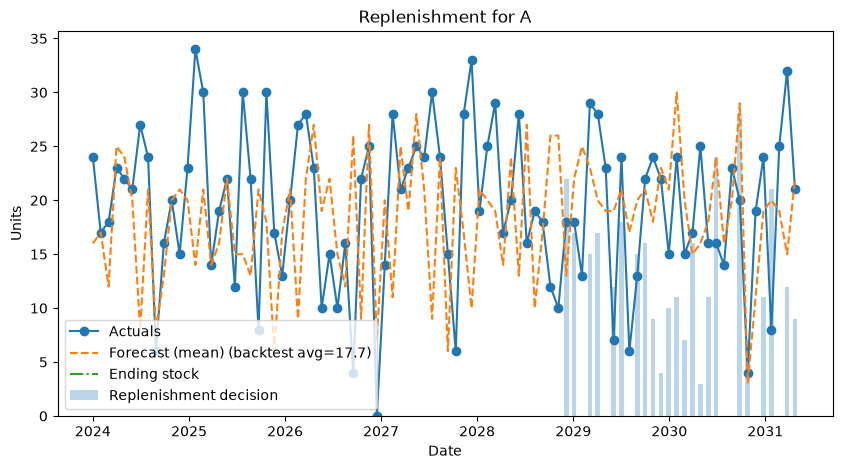

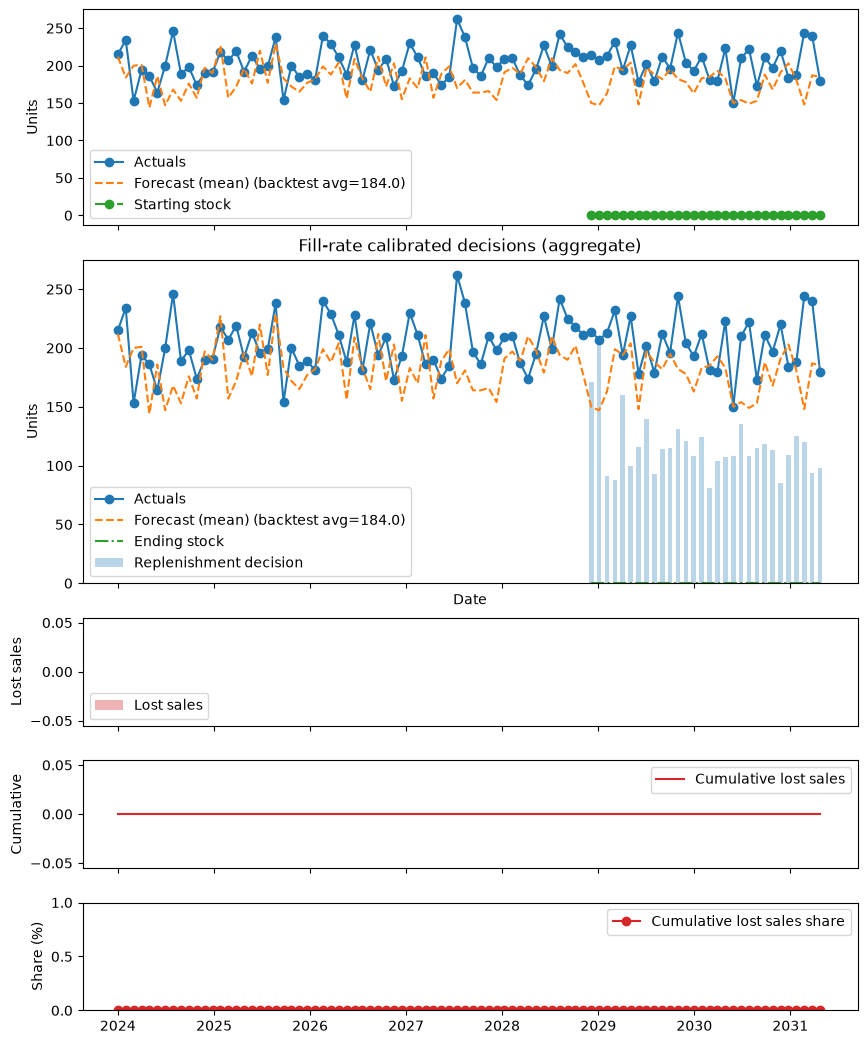

In [6]:
example_id = decisions_df["unique_id"].iloc[0]
plot_replenishment_decisions(rows_df, decisions_df, unique_id=example_id)
plot_replenishment_decisions(rows_df, decisions_df, aggregate=True, title="Fill-rate calibrated decisions (aggregate)")